<a href="https://colab.research.google.com/github/droyktton/ICNPG/blob/master/Clases/Clases_cusolver/ICNPG_Aleatorios_AlgebraLineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

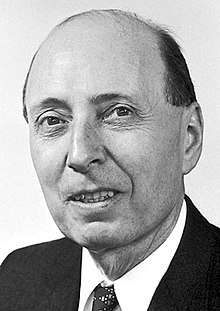

# Eugene Wigner

Eugene Wigner (1902-1995) fue un físico y matemático húngaro-estadounidense, uno de los científicos más influyentes del siglo XX. Nació en Budapest, Hungría, y se formó en la Universidad de Budapest y en la Universidad Técnica de Berlín, donde estuvo en contacto con figuras destacadas de la física y las matemáticas. Su trabajo abarcó varias áreas, pero se le conoce principalmente por su contribución a la mecánica cuántica, la teoría de la simetría y la física nuclear.

Principales logros de Wigner:

* Teoría de la simetría y grupos de Lie: Wigner hizo una contribución fundamental a la teoría de la simetría, que se aplica en la física de partículas y la teoría cuántica. Desarrolló una importante formulación sobre cómo las simetrías se relacionan con las leyes físicas. En su trabajo sobre grupos de Lie, mostró cómo las simetrías se pueden describir mediante transformaciones matemáticas y matrices, lo que más tarde influyó enormemente en la física de partículas y la teoría cuántica.

* Mecánica cuántica: Wigner fue un pionero en la formulación de la mecánica cuántica. Es conocido por su trabajo en el desarrollo de la "función de distribución cuántica" (función de Wigner), que describe un sistema cuántico en términos de probabilidades en una representación clásica de las trayectorias de partículas.

* Teoría nuclear: Fue una figura clave en la teoría nuclear, especialmente en la comprensión de las interacciones nucleares. Aportó al desarrollo de la física nuclear, ayudando a explicar las interacciones entre nucleones (protones y neutrones).

* Desarrollo de la teoría de la física de partículas: Wigner tuvo una influencia significativa en el desarrollo de la teoría de partículas elementales y la comprensión de los conceptos de simetría en las interacciones fundamentales.

* Premios y Reconocimientos:
En 1963, Wigner fue galardonado con el Premio Nobel de Física por sus contribuciones al desarrollo de la mecánica cuántica, particularmente por su trabajo sobre los principios fundamentales de la teoría de los grupos y sus aplicaciones en la física de partículas y la teoría nuclear.

* Enfoque filosófico:
Además de sus logros científicos, Wigner también fue conocido por sus reflexiones filosóficas sobre la naturaleza de la ciencia y la realidad cuántica. Uno de sus ensayos más conocidos, "La irreducibilidad de la descripción cuántica de la naturaleza", aborda la cuestión de si es posible explicar completamente los fenómenos cuánticos en términos de una visión determinista y clásica del universo. Wigner se mostró escéptico sobre la capacidad de la física clásica para describir de manera adecuada los fenómenos cuánticos.

* Legado:
El legado de Wigner sigue vivo en muchas áreas de la física moderna, como la física de partículas, la física cuántica y la teoría de la información cuántica. Su influencia perdura, ya que sus conceptos sobre simetrías y funciones cuánticas continúan siendo fundamentales en el desarrollo de la teoría física.

Wigner también es conocido por ser una de las figuras clave en la creación de la teoría cuántica moderna, junto con otros gigantes de la física como Niels Bohr, Werner Heisenberg, y Erwin Schrödinger.

**Chisme**:
La hermana de Eugene Wigner, Grete Wigner, se casó con el físico teórico Paul Dirac, quien es conocido por su trabajo en la mecánica cuántica y la teoría de la relatividad. Grete Wigner, la hermana de Eugene, era matemática y trabajó en varias áreas de la ciencia, aunque su carrera no fue tan reconocida como la de su hermano o su cuñado. La relación entre Paul Dirac y Grete Wigner fue una faceta menos conocida de la vida personal de estos dos grandes físicos.

# Espectro de una matriz aleatoria

Las matrices aleatorias tienen numerosas aplicaciones en teoría de números, física de la materia condensada, mecánica cuántica, ingeniería de comunicaciones, finanzas, etc. Sus propiedades espectrales universales son en particular de mucho interés.

Por ejemplo, un hamiltoniano puede ser representado por una matriz aleatoria cuando se encuentra en un sistema complejo cuántico donde el comportamiento del sistema no depende de un modelo determinista explícito, sino que está regido por la aleatoriedad de sus interacciones. Esto ocurre en situaciones donde los detalles del sistema son demasiado complejos o cuando el sistema es lo suficientemente grande como para que sus interacciones puedan considerarse estadísticamente distribuídas.


En este ejercicio podrá redescubrir, despues de Eugene Paul Wigner en 1955, el resultado más
famoso al respecto, la famosa ``[ley del semicírculo](https://en.wikipedia.org/wiki/Wigner_semicircle_distribution)'', valida para matrices aleatorias gausianas simétricas. Puede usar CUDA C/C++ o python CUDA.

* Usando un kernel o algoritmo paralelo Element-Wise escriba una función que construya en la GPU una matriz simétrica de $n \times n$ elementos reales, aleatorios, independientes, e identicamente distribuídos, con un
a distribución gaussiana de media cero y varianza uno.
* Para una matriz de $n = 4096$ calcule el espectro de autovalores usando la rutina cusolverDnSsyevd (
¿es la rutina adecuada para el tipo de matriz?) y grafique el histograma de los mismos. ¿Que forma tiene el histograma? (investigar la respuesta para $n\to \infty$).
* Para $256$ matrices independientes de $n=256$ obtenga los autovalores de cada una usando cusolverDnDsyevjBatched. Grafique el histograma de todos los autovalores y compare con el caso anterior.


# Preguntas

* ¿Como generamos una matriz aleatoria simétrica?

## versión CUDA C

In [ ]:
%%writefile test.cu

#include <stdio.h>
#include <stdlib.h>
#include <curand.h>
#include <cusolverDn.h>
#include <cuda_runtime.h>
#include <fstream>

// Matrix size
#define N 512

unsigned int GLOBALSEED = 1234;

// Error checking macro
#define CUDA_CALL(call) \
    do { \
        cudaError_t err = call; \
        if (err != cudaSuccess) { \
            fprintf(stderr, "CUDA Error: %s (at %s:%d)\n", cudaGetErrorString(err), __FILE__, __LINE__); \
            exit(EXIT_FAILURE); \
        } \
    } while (0)

#define CUSOLVER_CALL(call) \
    do { \
        cusolverStatus_t status = call; \
        if (status != CUSOLVER_STATUS_SUCCESS) { \
            fprintf(stderr, "cuSOLVER Error (at %s:%d)\n", __FILE__, __LINE__); \
            exit(EXIT_FAILURE); \
        } \
    } while (0)

// Function to generate a random normal matrix using cuRAND
void generate_random_matrix(float *d_A) {
    curandGenerator_t gen;
    curandCreateGenerator(&gen, CURAND_RNG_PSEUDO_DEFAULT);
    curandSetPseudoRandomGeneratorSeed(gen, 1234ULL);
    curandGenerateNormal(gen, d_A, N * N, 0.0f, 1.0f);
    curandDestroyGenerator(gen);
}

// Kernel to enforce symmetry: A[i][j] = A[j][i]
__global__ void enforce_symmetry(float *A, int n) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;

    // We only need to process one half of the off-diagonal elements
    if (row < n && col < n && row > col) {
        // Overwrite the lower triangle with the upper triangle values
        A[row * n + col] = A[col * n + row];
    }
}

// Kernel to calculate A = (A + A^T) / 2
__global__ void average_with_transpose(float *A, int n) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;

    // We only need to process the lower triangle and diagonal to avoid redundant work
    // However, for simplicity in a basic kernel, we process the whole matrix
    // or just one half and update both symmetric spots.
    if (row < n && col < n && row >= col) {
        float val1 = A[row * n + col];
        float val2 = A[col * n + row];
        float avg = (val1 + val2) * 0.5f;

        // Apply the average to both symmetric positions
        A[row * n + col] = avg;
        A[col * n + row] = avg;
    }

}

void generate_symmetric_random_matrix(float *d_A, int n, unsigned int seed) {
    curandGenerator_t gen;
    curandCreateGenerator(&gen, CURAND_RNG_PSEUDO_DEFAULT);
    curandSetPseudoRandomGeneratorSeed(gen, seed);

    // 1. Generate the initial random normal matrix
    curandGenerateNormal(gen, d_A, n * n, 0.0f, 1.0f);

    dim3 threadsPerBlock(16, 16);
    dim3 numBlocks((n + threadsPerBlock.x - 1) / threadsPerBlock.x,
                   (n + threadsPerBlock.y - 1) / threadsPerBlock.y);

    // 2. Enforce symmetry using a kernel
    //enforce_symmetry<<<numBlocks, threadsPerBlock>>>(d_A, n);

    // (A = (A + A^T) / 2 is another option, but mirroring is faster
    average_with_transpose<<<numBlocks, threadsPerBlock>>>(d_A, n);

    // Cleanup
    curandDestroyGenerator(gen);
}

// Compute eigenvalues using cuSOLVER
void compute_eigenvalues(float *d_A, float *d_W) {
    cusolverDnHandle_t cusolverH;
    cusolverDnCreate(&cusolverH);

    int work_size = 0;
    float *d_work = nullptr;
    int *devInfo = nullptr;

    CUDA_CALL(cudaMalloc((void**)&devInfo, sizeof(int)));

    // Compute workspace size
    CUSOLVER_CALL(cusolverDnSsyevd_bufferSize(
        cusolverH, CUSOLVER_EIG_MODE_VECTOR, CUBLAS_FILL_MODE_LOWER, N, d_A, N, d_W, &work_size));

    CUDA_CALL(cudaMalloc((void**)&d_work, work_size * sizeof(float)));

    // Compute eigenvalues
    CUSOLVER_CALL(cusolverDnSsyevd(
        cusolverH, CUSOLVER_EIG_MODE_VECTOR, CUBLAS_FILL_MODE_LOWER, N, d_A, N, d_W, d_work, work_size, devInfo));

    // Free memory
    CUDA_CALL(cudaFree(d_work));
    CUDA_CALL(cudaFree(devInfo));
    cusolverDnDestroy(cusolverH);
}

int main(int argc, char **argv) {
    float *d_A, *d_W;

    GLOBALSEED = atoi(argv[1]);

    // Allocate memory
    CUDA_CALL(cudaMalloc((void**)&d_A, N * N * sizeof(float)));
    CUDA_CALL(cudaMalloc((void**)&d_W, N * sizeof(float)));

    // Generate random matrix
    // generate_random_matrix(d_A);
    generate_symmetric_random_matrix(d_A, N, GLOBALSEED);

    // Compute eigenvalues
    compute_eigenvalues(d_A, d_W);

    // Copy eigenvalues back to host
    float *h_W = (float*)malloc(N * sizeof(float));
    CUDA_CALL(cudaMemcpy(h_W, d_W, N * sizeof(float), cudaMemcpyDeviceToHost));

    // Print first 10 eigenvalues
    printf("First 10 Eigenvalues:\n");
    for (int i = 0; i < 10; i++) {
        printf("%f\n", h_W[i]);
    }

    std::ofstream outputFile("eigenvalues.txt");
    if (outputFile.is_open()) {
        outputFile << "Eigenvalues:\n";
        for (int i = 0; i < N; i++)
            outputFile << h_W[i] << std::endl;
    }

    // Cleanup
    CUDA_CALL(cudaFree(d_A));
    CUDA_CALL(cudaFree(d_W));
    free(h_W);

    return 0;
}


Overwriting test.cu


In [ ]:
!nvcc -arch=sm_75 test.cu -lcurand -lcusolver -o test; ./test 1234

First 10 Eigenvalues:
-31.404688
-30.908314
-30.555098
-30.201746
-30.032122
-29.719883
-29.177229
-29.081348
-28.963259
-28.709566


In [ ]:
%%bash

rm -f todoseigen.dat

for((i=1234;i<1234+100;i++))
do
  ./test $i > zzz
  cat eigenvalues.txt >> todoseigen.dat
done

51200


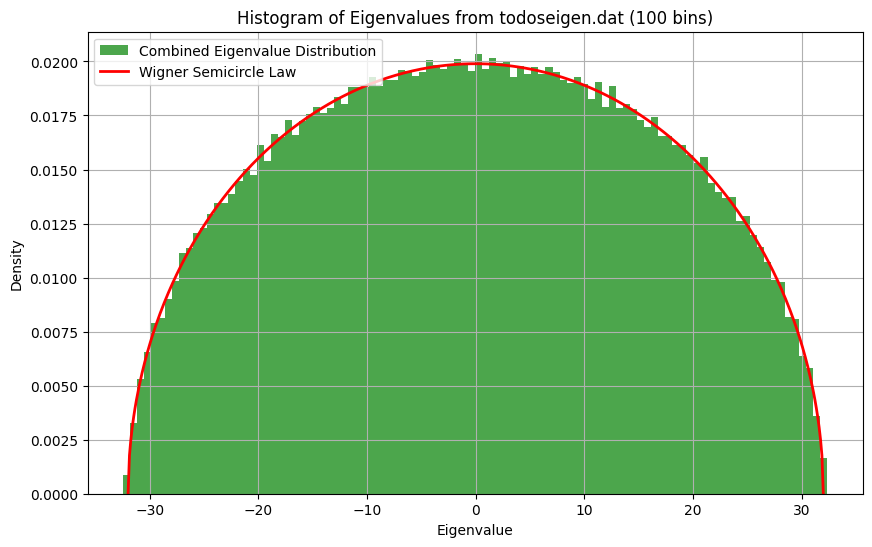

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize an empty list to store eigenvalues
all_eigenvalues = []

# Read the todoseigen.dat file
with open('todoseigen.dat', 'r') as f:
    for line in f:
        # Skip lines that start with 'Eigenvalues:'
        if line.startswith('Eigenvalues:'):
            continue
        try:
            # Convert the line to a float and add to the list
            all_eigenvalues.append(float(line.strip()))
        except ValueError:
            # Handle any non-numeric lines if necessary (e.g., empty lines)
            continue

# Convert the list to a NumPy array for histogram plotting
eigenvalues_np = np.array(all_eigenvalues)

# The problematic line: 'shape' is an attribute, not a method.
# Corrected line:
print(len(eigenvalues_np))

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(eigenvalues_np, bins=100, density=True, alpha=0.7, color='g', label='Combined Eigenvalue Distribution')


# Wigner semicircle law
N = 512
R = np.sqrt(2 * N)  # Theoretical radius
x_vals = np.linspace(-R, R, 500)
rho = (1 / (np.pi * N)) * np.sqrt(2 * N - x_vals**2)
rho = np.clip(rho, 0, None)  # Avoid NaN outside range

# Plot Wigner semicircle law
plt.plot(x_vals, rho, 'r-', linewidth=2, label="Wigner Semicircle Law")


# Add labels and title
plt.xlabel("Eigenvalue")
plt.ylabel("Density")
plt.title("Histogram of Eigenvalues from todoseigen.dat (100 bins)")
plt.legend()
plt.grid(True)
plt.show()

## Version cupy

51200


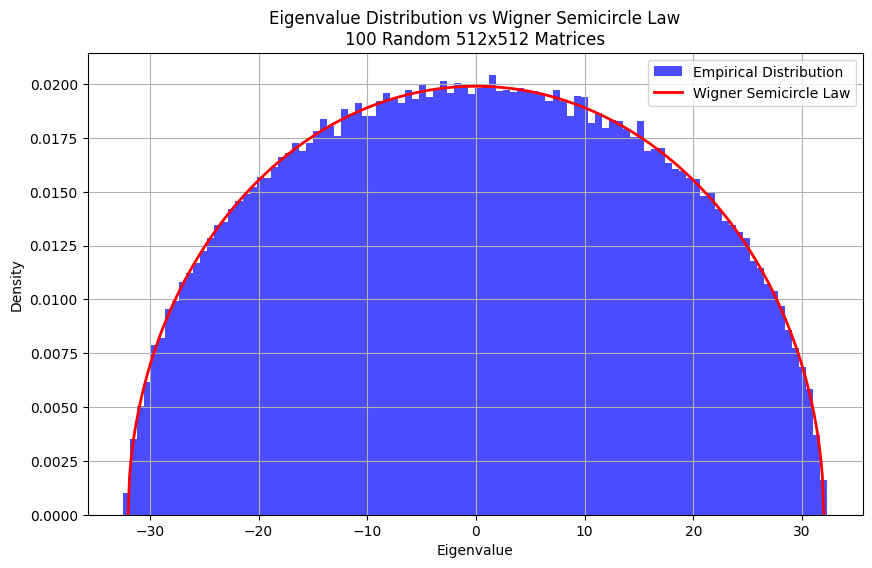

In [ ]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

# Matrix size
N = 512
num_matrices = 100  # Number of matrices to sample eigenvalues from

# Collect all eigenvalues
eigenvalues = []

for _ in range(num_matrices):
    # Generate a random symmetric matrix
    A = cp.random.randn(N, N)
    A = (A + A.T) / 2  # Make it symmetric

    # Compute eigenvalues
    w = cp.linalg.eigh(A)[0]  # Only eigenvalues
    eigenvalues.append(w)

# Convert list to a single array
eigenvalues = cp.concatenate(eigenvalues)

print(len(eigenvalues_np))


# Convert to NumPy for plotting
eigenvalues_np = cp.asnumpy(eigenvalues)

# Compute histogram
bins = 100
hist, bin_edges = np.histogram(eigenvalues_np, bins=bins, density=True)

# Wigner semicircle law
R = np.sqrt(2 * N)  # Theoretical radius
x_vals = np.linspace(-R, R, 500)
rho = (1 / (np.pi * N)) * np.sqrt(2 * N - x_vals**2)
rho = np.clip(rho, 0, None)  # Avoid NaN outside range

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(eigenvalues_np, bins=bins, density=True, alpha=0.7, color='b', label="Empirical Distribution")

# Plot Wigner semicircle law
plt.plot(x_vals, rho, 'r-', linewidth=2, label="Wigner Semicircle Law")

# Labels and title
plt.xlabel("Eigenvalue")
plt.ylabel("Density")
plt.title(f"Eigenvalue Distribution vs Wigner Semicircle Law\n{num_matrices} Random {N}x{N} Matrices")
plt.legend()
plt.grid()
plt.show()


In [ ]:
!find / -name "cudss.h"

find: ‘/proc/64/task/64/net’: Invalid argument
find: ‘/proc/64/net’: Invalid argument
